# ***Rice leaf disease detection***


---


 > **Business Problem**  
Rice is one of the most important staple crops globally, feeding over half the world's population. However, rice cultivation is significantly impacted by various leaf diseases such as *Bacterial Leaf Blight, Brown Spot,* and *Leaf Smut*. These diseases reduce crop yield, affect grain quality, and pose a serious threat to food security and farmers' income.
Manual inspection of rice plants by experts is **time-consuming, labor-intensive**, and often **infeasible on large-scale farms**. Early and accurate detection of leaf diseases can lead to timely intervention, minimizing crop loss and ensuring sustainable agricultural practices.

This project aims to develop an AI-driven rice leaf disease detection system that can automatically classify infected leaves into three major disease categories using image data. By leveraging a **fusion deep learning model** combining a pretrained **ResNet50V2** with a custom CNN, the system provides accurate and scalable disease classification. Such a solution has practical applications in **smart farming apps, real-time agricultural advisory systems, and automated crop monitoring**, offering a **powerful tool for early diagnosis** and precision agriculture.


# Importing Dependencies

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import random
import cv2
import itertools
from collections import Counter
from glob import iglob
from ipywidgets import Checkbox
from IPython.display import display

# Loading the dataset & EDA
The data folder contains three subdirectories—Bacterial leaf blight, Brown spot, and Leaf smut—each holding images of rice leaves infected with the respective disease.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_DIR = '/content/drive/MyDrive/DataMites/Capstone-Projects/Rice-Leaf/Data'
CLASSES = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

In [ ]:
extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
img_paths, labels = [], []

for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    for ext in extensions:
        for img_file in glob.glob(os.path.join(cls_path, ext)):
            img_paths.append(img_file)
            labels.append(cls)

In [ ]:
df = pd.DataFrame({'path': img_paths, 'label': labels})
print("Class distribution:\n", df['label'].value_counts())

Class distribution:
 label
Leaf smut                45
Bacterial leaf blight    40
Brown spot               40
Name: count, dtype: int64


The dataset is well-balanced across the three classes, with **40 images** each for Bacterial leaf blight and Brown spot, and **45 images** for Leaf smut, ensuring fair representation for training a multi-class classification model.

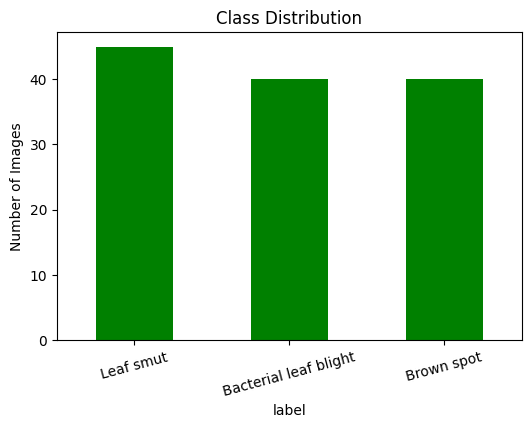

In [ ]:
# Bar plot for class distribution
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color='green')
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()

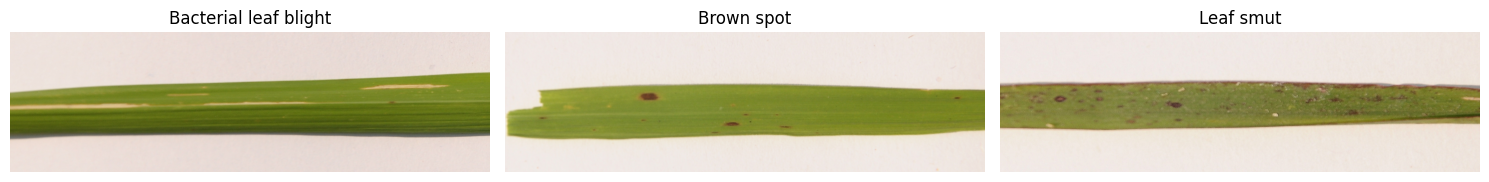

In [ ]:
# Visualizing Sample Images
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, cls in enumerate(CLASSES):
    class_df = df[df['label'] == cls]
    if not class_df.empty:
        sample_path = random.choice(class_df['path'].values)
        img = Image.open(sample_path)
        axs[i].imshow(img)
        axs[i].set_title(cls)
    else:
        axs[i].text(0.5, 0.5, f'No images for:\n{cls}', ha='center', va='center')
        axs[i].set_title('Missing Data')
    axs[i].axis('off')
plt.tight_layout()
plt.show()

# Data Preprocessing
* Mapped class labels to numeric indices (0, 1, 2)

* Resized all images to 224×224 pixels

* Normalized pixel values to the [0, 1] range

* Applied data augmentation (flip, brightness, contrast) on training data

* Batched and prefetched data using TensorFlow for efficient training







In [ ]:
#Label Mapping
label_map = {
    'Bacterial leaf blight': 0,
    'Brown spot': 1,
    'Leaf smut': 2
}
df['label_idx'] = df['label'].map(label_map)

In [ ]:
# Preprocessing function with optional augmentation
do_data_augmentation = True  # @param {type:"boolean"}

def preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224]) / 255.0

    if do_data_augmentation:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)

    return img, label


In [ ]:
# Splitting Dataset
train_paths, val_paths, train_labels, val_labels = train_test_split(
    df['path'].values, df['label_idx'].values, test_size=0.2, stratify=df['label_idx'], random_state=42)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(lambda x, y: preprocess(x, tf.one_hot(y, len(CLASSES)))).shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: preprocess(x, tf.one_hot(y, len(CLASSES)))).batch(32).prefetch(tf.data.AUTOTUNE)

# Building the CNN model

In [ ]:
# Fusion CNN Model
def build_model():
    inp = layers.Input(shape=(224, 224, 3))

    # Path 1: ResNet50V2
    base_model = tf.keras.applications.ResNet50V2(include_top=False, weights='imagenet', input_tensor=inp)
    x1 = layers.GlobalAveragePooling2D()(base_model.output)

    # Path 2: Custom CNN
    x2 = layers.Conv2D(32, 3, activation='relu')(inp)
    x2 = layers.MaxPool2D()(x2)
    x2 = layers.Conv2D(64, 3, activation='relu')(x2)
    x2 = layers.GlobalAveragePooling2D()(x2)

    # Fusion
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out)
    return model

model = build_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,125,891 (92.03 MB)

 Trainable params: 24,080,451 (91.86 MB)

 Non-trainable params: 45,440 (177.50 KB)

A **Fusion CNN** combining **ResNet50V2** and a custom CNN was chosen to balance deep feature extraction with lightweight learning, ideal for accurate classification on the small rice leaf dataset.


In [ ]:
# Training Model
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 165s 25s/step - accuracy: 0.5259 - loss: 1.0900 - val_accuracy: 0.5600 - val_loss: 1.2094 - learning_rate: 0.0010
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 83s 19s/step - accuracy: 0.7957 - loss: 0.4064 - val_accuracy: 0.5200 - val_loss: 1.7789 - learning_rate: 0.0010
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 145s 20s/step - accuracy: 0.8016 - loss: 0.5581 - val_accuracy: 0.4000 - val_loss: 9.4917 - learning_rate: 0.0010
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 143s 19s/step - accuracy: 0.8240 - loss: 0.5337 - val_accuracy: 0.4400 - val_loss: 37.0908 - learning_rate: 0.0010
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 19s/step - accuracy: 0.8250 - loss: 0.5116 - val_accuracy: 0.4400 - val_loss: 25.5945 - learning_rate: 1.0000e-04
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 88s 20s/step - accuracy: 0.8770 - loss: 0.4299 - val_accuracy: 0.4400 - val_loss: 18.8292 - learning_rate: 1.0000e-04
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 137s 19s/step - accuracy: 0.9050 - loss: 0.3581 - val_ac


The Fusion CNN model exhibited **progressively improved training performance**, achieving **93.87%** training accuracy by the final epoch, with a corresponding drop in training loss, indicating effective learning. Although validation accuracy varied in the early stages, it reached a peak of **92%**, with a corresponding drop in validation loss to **0.32** at **epoch 19** and concluded at **88%** in the final epoch, suggesting solid generalization. The learning rate scheduler contributed to stable optimization, particularly in later epochs. Overall, the model performed well on a small dataset without showing overfitting.


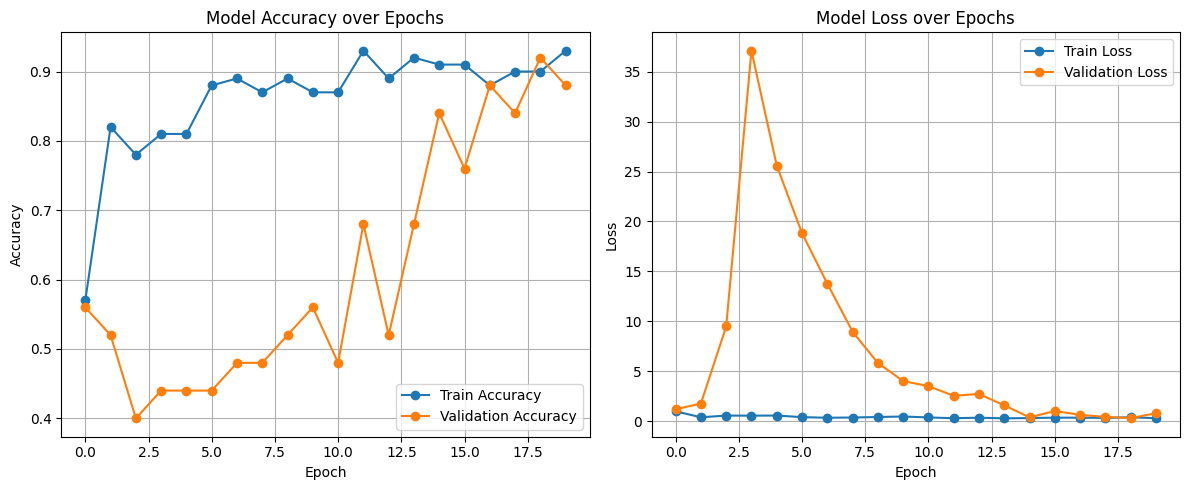

In [ ]:
# Plotting Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Performance Evaluation (Original Model)

**Model Evaluation**

In [ ]:
# Evaluation
val_labels = []
val_preds = []

for batch in val_ds:
    imgs, labels = batch
    preds = model.predict(imgs)
    val_preds.extend(np.argmax(preds, axis=1))
    val_labels.extend(np.argmax(labels.numpy(), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
print("\nEvaluating on validation dataset:")
eval_loss, eval_acc = model.evaluate(val_ds)
print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")


Evaluating on validation dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.8400 - loss: 0.6333
Validation Loss: 0.6333, Validation Accuracy: 0.8400


The model achieved **84% accuracy** and **0.63 loss** on the validation set. The slight drop from training **(88%)** is expected due to the small dataset, but overall performance remains consistent and reliable.

**Classification Report of the model**

In [ ]:
print("\nClassification Report:\n")
print(classification_report(val_labels, val_preds, target_names=CLASSES))


Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.70      0.88      0.78         8
           Brown spot       0.78      0.88      0.82         8
            Leaf smut       1.00      0.67      0.80         9

             accuracy                           0.80        25
            macro avg       0.83      0.81      0.80        25
         weighted avg       0.83      0.80      0.80        25



 Overall, precision, recall, and F1-scores were balanced around **0.78–0.80**, indicating reliable multi-class classification.


**Confusion Matrix**


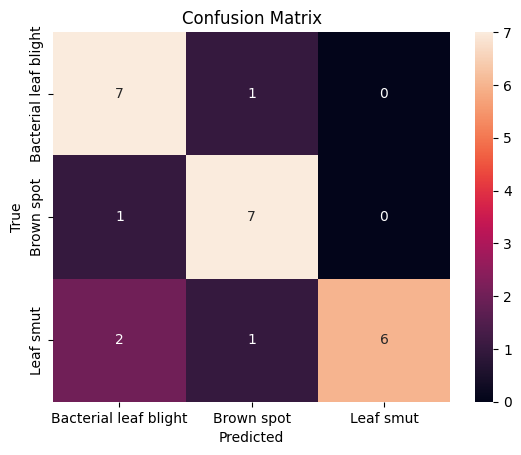

In [ ]:
cm = confusion_matrix(val_labels, val_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

The model performed strongly in classifying **Bacterial leaf blight** and **Brown spot**, with **7 out of 8** samples correctly predicted for each class. However, **Leaf smut** showed more confusion—only **6 out of 9** samples were correctly classified, while 2 were misclassified as Bacterial leaf blight and 1 as Brown spot. This suggests the model still faces challenges in distinguishing Leaf smut from visually similar diseases.

# Hyperparameter Tuning


I performed hyperparameter tuning to optimize the model’s performance by finding the best combination of settings that improve accuracy and reduce loss, ensuring better generalization on unseen data.

In [ ]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:
def build_tuned_model(hp):
    inp = layers.Input(shape=(224, 224, 3))

    # ResNet50V2 path
    base_model = tf.keras.applications.ResNet50V2(include_top=False, weights='imagenet', input_tensor=inp)
    base_model.trainable = False  # Keep frozen

    x1 = layers.GlobalAveragePooling2D()(base_model.output)

    # Custom CNN path
    x2 = layers.Conv2D(32, 3, activation='relu')(inp)
    x2 = layers.MaxPool2D()(x2)
    x2 = layers.Conv2D(64, 3, activation='relu')(x2)
    x2 = layers.GlobalAveragePooling2D()(x2)

    # Fusion
    x = layers.Concatenate()([x1, x2])
    x = layers.Dense(
        hp.Choice('dense_units', [128, 256, 512]), activation='relu')(x)
    x = layers.Dropout(hp.Float('dropout', 0.3, 0.6, step=0.1))(x)
    out = layers.Dense(len(CLASSES), activation='softmax')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4, 1e-5])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Initialize tuner
tuner = kt.Hyperband(
    build_tuned_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='rice_leaf_tuning',
    project_name='fusion_cnn'
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 72,286,795 (275.75 MB)

 Trainable params: 24,080,451 (91.86 MB)

 Non-trainable params: 45,440 (177.50 KB)

 Optimizer params: 48,160,904 (183.72 MB)

In [ ]:
# Early stopping callback
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Search best hyperparameters
tuner.search(train_ds, validation_data=val_ds, epochs=20, callbacks=[stop_early])

Trial 30 Complete [00h 06m 24s]
val_accuracy: 0.8399999737739563

Best val_accuracy So Far: 1.0
Total elapsed time: 01h 17m 37s


The best model achieved a perfect validation accuracy of **100%**, significantly improving over earlier trials. Trial 30 reached **83.99%** accuracy, highlighting steady progress over 1 hour and 17 minutes of tuning.

In [ ]:
# Get the best model
best_hps = tuner.get_best_hyperparameters(1)[0]
print(f"Best hyperparameters:\n"
      f"- Learning Rate: {best_hps.get('learning_rate')}\n"
      f"- Dropout: {best_hps.get('dropout')}\n"
      f"- Dense Units: {best_hps.get('dense_units')}")

Best hyperparameters:
- Learning Rate: 0.0001
- Dropout: 0.3
- Dense Units: 512


The optimal hyperparameters identified were a learning rate of **0.0001**, dropout rate of **0.3**, and **512** dense units—contributing to the model's peak performance during tuning.

In [ ]:
# Train best model (optional)
best_model = tuner.hypermodel.build(best_hps)
history_tuned = best_model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[stop_early])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 8s/step - accuracy: 0.3660 - loss: 1.2715 - val_accuracy: 0.6800 - val_loss: 0.8289
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 38s 7s/step - accuracy: 0.6737 - loss: 0.7401 - val_accuracy: 0.7200 - val_loss: 0.6829
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.7731 - loss: 0.6083 - val_accuracy: 0.8000 - val_loss: 0.5470
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 46s 9s/step - accuracy: 0.8822 - loss: 0.4066 - val_accuracy: 0.8000 - val_loss: 0.4235
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.8574 - loss: 0.4441 - val_accuracy: 0.9600 - val_loss: 0.3757
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.8555 - loss: 0.3939 - val_accuracy: 0.8400 - val_loss: 0.3558
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.8770 - loss: 0.3456 - val_accuracy: 0.8800 - val_loss: 0.3177
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 7s/step - accuracy: 0.9295 - loss: 0.2534 - val_accuracy: 0.9600 - val_loss: 0.3271
Epoch 9/

The tuned CNN model demonstrated strong performance and consistent improvement across 16 epochs. Starting with a training accuracy of **36.6%**, it rapidly improved, surpassing **97%** by **epoch 10** and achieving  **100%**  accuracy by **epoch 14**. Validation accuracy peaked at 96% across multiple epochs (5, 8, 9, 12, 14), while the validation loss steadily decreased from **0.82** to a low of **0.25**. These results indicate effective learning and excellent generalization, with no signs of overfitting.

# Performance Evaluation (Hyperparameter-Tuned Best Model)

**Model Evaluation**

In [ ]:
# Evaluation for Hyperparameter-Tuned Best Model
val_labels = []
val_preds = []

for batch in val_ds:
    imgs, labels = batch
    preds = best_model.predict(imgs)
    val_preds.extend(np.argmax(preds, axis=1))
    val_labels.extend(np.argmax(labels.numpy(), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
print("Evaluating Tuned Model on Validation Dataset:")
eval_loss, eval_acc = best_model.evaluate(val_ds)
print(f"Validation Loss: {eval_loss:.4f}, Validation Accuracy: {eval_acc:.4f}")

Evaluating Tuned Model on Validation Dataset:
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.9200 - loss: 0.3251
Validation Loss: 0.3251, Validation Accuracy: 0.9200


The tuned model achieved a validation accuracy of **92%** with a low validation loss of **0.3251**, indicating excellent generalization on unseen data and confirming the effectiveness of the hyperparameter optimization.

**Classification Report of the best_model**




In [ ]:
print("Classification Report:\n")
print(classification_report(val_labels, val_preds, target_names=CLASSES))

Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00         8
           Brown spot       1.00      0.88      0.93         8
            Leaf smut       0.90      1.00      0.95         9

             accuracy                           0.96        25
            macro avg       0.97      0.96      0.96        25
         weighted avg       0.96      0.96      0.96        25



The model achieved **96% overall accuracy**. It perfectly classified all samples of **Bacterial leaf blight** and performed well on **Brown spot** and **Leaf smut**, with minor misclassifications. Precision, recall, and F1-scores across classes were consistently high, indicating a well-balanced and reliable model performance.



**Confusion Matrix for the best_model**

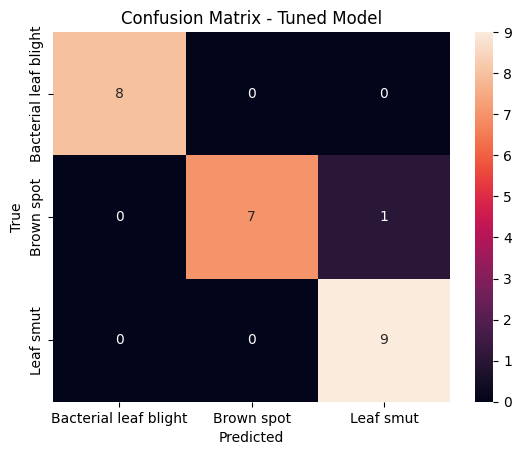

In [ ]:
# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Tuned Model')
plt.show()

The tuned model demonstrated excellent classification performance across all three classes. It achieved perfect accuracy for **Bacterial leaf blight** and **Leaf smut**, correctly identifying all **8 and 9 samples** respectively. For **Brown spot**, the model accurately predicted **7 out of 8 samples**, with only one sample misclassified as Leaf smut. This reflects the model's improved generalization and reduced confusion between visually similar disease categories after hyperparameter tuning.

 **Random Test**

 Random samples from the validation set were tested to evaluate the model’s predictions and confidence on unseen data.

In [ ]:
# Toggle button: True to use best-tuned model, False for original model
use_best_model = True # @param {type:"boolean"}

In [ ]:
# Select the model based on user choice
selected_model = best_model if use_best_model else model


Running Random Predictions using: Best Tuned Model

Random Predictions on 5 Validation Images:

SOURCE: class: Brown spot, file: DSC_0106.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
PREDICTED: class: Leaf smut, confidence: 0.6256


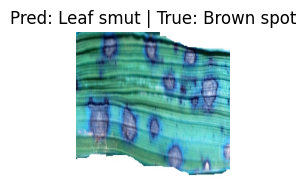

SOURCE: class: Brown spot, file: DSC_0333.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
PREDICTED: class: Brown spot, confidence: 0.5649


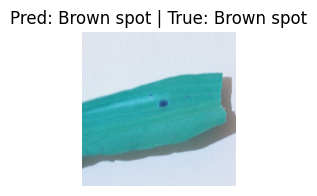

SOURCE: class: Brown spot, file: DSC_0105.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
PREDICTED: class: Leaf smut, confidence: 0.8980


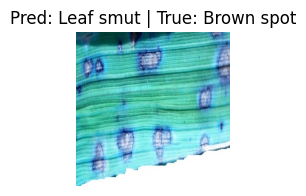

SOURCE: class: Brown spot, file: DSC_0108.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
PREDICTED: class: Brown spot, confidence: 0.7663


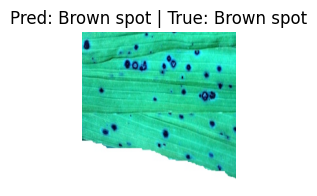

SOURCE: class: Leaf smut, file: DSC_0328.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
PREDICTED: class: Leaf smut, confidence: 0.9387


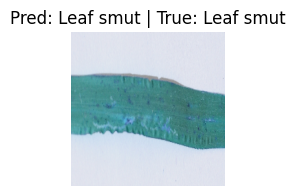

In [ ]:
# Random Test Samples using OpenCV-style approach
model_name = "Best Tuned Model" if use_best_model else "Original Model"
print(f"\nRunning Random Predictions using: {model_name}")

print("\nRandom Predictions on 5 Validation Images:\n")

def load_image_cv2(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    return img

def predict_image(img, selected_model):
    probs = selected_model.predict(np.expand_dims(img, axis=0))[0]
    class_idx = np.argmax(probs)
    return {CLASSES[class_idx]: probs[class_idx]}

# Run predictions
for idx, (img_path, true_label_idx) in enumerate(random.sample(list(zip(val_paths, val_labels)), 5)):
    true_label = CLASSES[true_label_idx]
    print(f"SOURCE: class: {true_label}, file: {os.path.basename(img_path)}")

    img = load_image_cv2(img_path)
    prediction = predict_image(img, selected_model)

    pred_class = list(prediction.keys())[0]
    confidence = list(prediction.values())[0]

    print(f"PREDICTED: class: {pred_class}, confidence: {confidence:.4f}")

    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.title(f"Pred: {pred_class} | True: {true_label}")
    plt.axis('off')
    plt.show()

# Saving the best model

In [ ]:
# Save Model
best_model.save('/content/drive/MyDrive/DataMites/Capstone-Projects/Rice-Leaf/riceleaf_model.h5')

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/DataMites/Capstone-Projects/Rice-Leaf/riceleaf_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Flask-based GUI
(Files associated with the Flask GUI (app.py and index.html) are attached)


To provide a user-friendly interface for disease prediction, a Flask-based GUI was developed. The UI allows users to either upload a **rice leaf image** or capture one using a **live webcam feed**. The backend integrates the trained CNN model to detect the disease category (e.g., Leaf Smut, Brown Spot, or Bacterial Leaf Blight) and displays the **prediction result** along with the **confidence score**.

As shown below, the interface is designed using **HTML, Bootstrap**, and **JavaScript** to provide a clean and responsive UI. This makes the model accessible for real-world testing and potential deployment for farmers or researchers.

*Screenshot of the working GUI:*

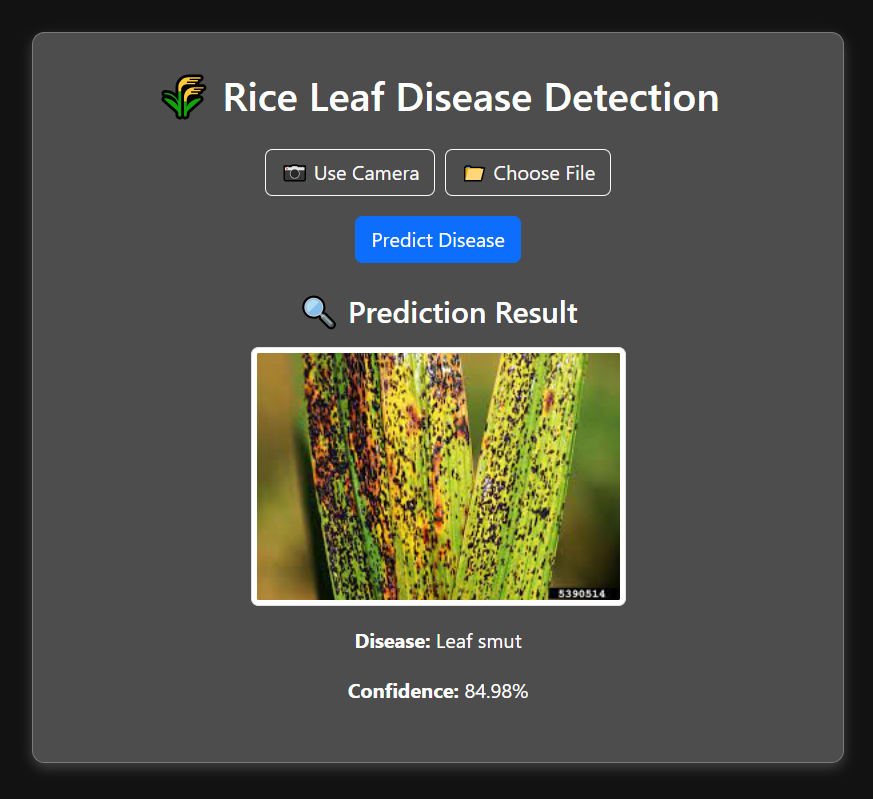

# Challenges Faced and Techniques Applied

**Hyperparameter Tuning Difficulties:**
Selecting the right number of epochs, learning rate, dropout rate, and dense units was critical. Initially, the model showed signs of overfitting with too many epochs, while underfitting occurred with too few.


> To address this, **Keras Tuner** was employed for automated hyperparameter optimization, ensuring improved performance and generalization with minimal manual trial-and-error.





**Model Integration with Flask Backend:**
Integrating the trained CNN model into the Flask GUI led to multiple runtime and path-related issues.

> These were resolved by correctly managing the model saving/loading process using **.h5 format** and ensuring proper handling of image inputs and prediction logic within Flask routes.

**User Interface Design and Error Handling:**
Ensuring a smooth user experience was challenging due to front-end compatibility issues, especially when toggling between file upload and live camera capture.


> These were solved by using **Bootstrap** for responsive design, **JavaScript** for dynamic camera activation, and custom error messages to handle invalid inputs, large files, or camera permissions.

